## Daily heat exposure analysis

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joypy import joyplot
import numpy as np

### Summary statistics
 - number of pregnancies by country (N)
 - proportion (% days) of heat days by country (Q1, Q3, median)
 - number of heatwave events by country (Q1, Q3, median)
 - average duration of heatwave events by country (Q1, Q3, median)

Proportions of heat days for each participant using different `heat day` definitions and different sources of temperature data.


ID | Definition | Threshold |
---|------------|-----------|
HD_P75| moderate | > $75 ^th $ percentile
HD_P90| high | > $90 ^th $ percentile
HD_P95| extreme | > $95 ^th $ percentile

In [2]:
out_dict = dict()
for source in ["ERA-5", "MERRA-2", "Dewpoint"]:
    out_df = pd.DataFrame()
    temp = pd.DataFrame()
    for level in ["facility", "village", "centroid"]:
        # proportion of heat days by participant, using ERA-5 data
        data = (
            pd.read_csv(
                f"../data/processed/heat_days/{level}-level/{source}_heat_days.csv"
            )
            # format values to pct
            .apply(lambda x: 100 * x if x.dtype == np.float64 else x)
        )
        for country in ["Total", "Gambia", "Kenya", "Mozambique"]:
            subset = (
                data.copy() if country == "Total" else data[data["Country"] == country]
            )
            # compute IQR for each heat definition
            for hd in ["hd_p75", "hd_p90", "hd_p95"]:
                Q1 = subset[hd].quantile(0.25)
                Q3 = subset[hd].quantile(0.75)
                median = subset[hd].median()
                temp.loc[hd, country] = f"{median:.2f} ({Q1:.2f} - {Q3:.2f})"
        temp["level"] = level

        out_df = pd.concat([out_df, temp])
    out_df["Heat exposure metric"] = (
        "ERA-5 T2MWET" if source == "Dewpoint" else f"{source} T2M"
    )
    out_dict[source] = out_df

In [3]:
anc_data = pd.read_csv("../data/interim/anc_daily_attendance.csv")
anc_data = (
    anc_data.groupby(["Country", "f2a_participant_id"]).size().groupby("Country").size()
)
# summarise total pregnancies by country as N
anc_data.loc["Total"] = anc_data.sum()
anc_data = pd.DataFrame(anc_data.to_dict(), index=["pregnancies"]).map(
    lambda x: f"{x:,}"
)

# using just village-centroid data since there are no differences with other levels
# to-do check this!!!
out_dict = {k: df[df["level"] == "village"] for k, df in out_dict.items()}

# put all data into the same table for reporting summary stats
final_df = pd.concat(
    [
        anc_data,
        out_dict["ERA-5"],
        out_dict["MERRA-2"],
        out_dict["Dewpoint"],
    ]
).drop(columns="level")

final_df.to_csv("../reports/longterm-heat-exposure-summary.csv")

Number of heatwave events and average duration (days) for each participant using different `heatwave` definitions from different data sources.

ID | Heat day threshold | Consecutive heat days
---|--------------------|----------------------
HW_1a| > $75 ^th $ percentile | >= 2
HW_1b| > $75 ^th $ percentile | >= 3
HW_1c| > $75 ^th $ percentile | >= 4
HW_2a| > $90 ^th $ percentile | >= 2
HW_2b| > $90 ^th $ percentile | >= 3
HW_2c| > $90 ^th $ percentile | >= 4
HW_3a| > $95 ^th $ percentile | >= 2
HW_3b| > $95 ^th $ percentile | >= 3
HW_3c| > $95 ^th $ percentile | >= 4


In [4]:
# Heat wave events count
out_dict = dict()
for source in ["ERA-5", "MERRA-2", "Dewpoint"]:
    out_df = pd.DataFrame()
    temp = pd.DataFrame()
    for level in ["facility", "village", "centroid"]:
        # counts of heatwave events by participant, using ERA-5 data
        data = pd.read_csv(
            f"../data/processed/heat_waves/{level}-level/{source}_heat_waves.csv"
        )
        for country in ["Total", "Gambia", "Kenya", "Mozambique"]:
            subset = (
                data.copy() if country == "Total" else data[data["Country"] == country]
            )
            # compute IQR for each heat definition
            for i in range(1, 4):
                for alph in ["a", "b", "c"]:
                    # heat wave definition
                    hw = f"hw{i}{alph}_num"
                    Q1 = subset[hw].quantile(0.25)
                    Q3 = subset[hw].quantile(0.75)
                    median = subset[hw].median()
                    temp.loc[hw[:-4], country] = f"{median:.0f} ({Q1:.0f} - {Q3:.0f})"

        temp["level"] = level

        out_df = pd.concat([out_df, temp])

    out_df["Heat exposure metric"] = (
        "ERA-5 T2MWET" if source == "Dewpoint" else f"{source} T2M"
    )
    out_dict[source] = out_df

In [5]:
# using just village-centroid data since there are no differences with other levels
# to-do check this!!!
out_dict = {k: df[df["level"] == "village"] for k, df in out_dict.items()}
heatwave_counts = pd.concat(
    [
        out_dict["ERA-5"],
        out_dict["MERRA-2"],
        out_dict["Dewpoint"],
    ]
).drop(columns="level")

In [6]:
# Heat wave events duration
out_dict = dict()
for source in ["ERA-5", "MERRA-2", "Dewpoint"]:
    out_df = pd.DataFrame()
    temp = pd.DataFrame()
    for level in ["facility", "village", "centroid"]:
        # duration of heatwaves by participant, using ERA-5 data
        data = pd.read_csv(
            f"../data/processed/heat_waves/{level}-level/{source}_heat_waves.csv"
        )
        for country in ["Total", "Gambia", "Kenya", "Mozambique"]:
            subset = (
                data.copy() if country == "Total" else data[data["Country"] == country]
            )
            # compute IQR for each heat definition
            for i in range(1, 4):
                for alph in ["a", "b", "c"]:
                    # heat wave definition
                    hw = f"hw{i}{alph}_avg"
                    Q1 = subset[hw].quantile(0.25)
                    Q3 = subset[hw].quantile(0.75)
                    median = subset[hw].median()
                    temp.loc[hw[:-4], country] = f"{median:.1f} ({Q1:.1f} - {Q3:.1f})"

        temp["level"] = level

        out_df = pd.concat([out_df, temp])

    out_df["Heat exposure metric"] = (
        "ERA-5 T2MWET" if source == "Dewpoint" else f"{source} T2M"
    )
    out_dict[source] = out_df

In [7]:
# using just village-centroid data since there are no differences with other levels
# to-do check this!!!
out_dict = {k: df[df["level"] == "village"] for k, df in out_dict.items()}
heatwave_duration = pd.concat(
    [
        out_dict["ERA-5"],
        out_dict["MERRA-2"],
        out_dict["Dewpoint"],
    ]
).drop(columns="level")

In [8]:
final_df = pd.merge(
    heatwave_counts,
    heatwave_duration,
    left_on=[heatwave_counts.index, "Heat exposure metric"],
    right_on=[heatwave_duration.index, "Heat exposure metric"],
    suffixes=("_count", "_duration"),
    validate="1:1",
)
final_df.to_csv("../reports/shortterm-heatwave-exposure-summary.csv", index=False)

### Analysing extreme heat days

- Health facility level analysis

In [3]:
# compare proportions of extreme heat days using ERA-5 and MERRA-2 datasets
era5 = pd.read_csv("../data/processed/heat_days/facility-level/ERA-5_heat_days.csv")
merra2 = pd.read_csv("../data/processed/heat_days/facility-level/MERRA-2_heat_days.csv")
dewpoint = pd.read_csv(
    "../data/processed/heat_days/facility-level/Dewpoint_heat_days.csv"
)

In [40]:
def extreme_heat_data(level="facility"):
    out_df = pd.DataFrame()

    for source in ["ERA-5", "MERRA-2", "Dewpoint"]:
        data = pd.read_csv(
            f"../data/processed/heat_days/{level}-level/{source}_heat_days.csv"
        )
        # x-axis
        data["Exposure metric"] = (
            "ERA-5 T2MWET" if source == "Dewpoint" else f"{source} T2M"
        )
        # combine data sources
        out_df = pd.concat([out_df, data], ignore_index=True)
    # Melt percentile columns
    df_long = out_df.melt(
        id_vars=["f2a_participant_id", "Country", "Exposure metric"],
        value_vars=["hd_p75", "hd_p90", "hd_p95"],
        var_name="heat_def",
        value_name="proportion",
    )
    return df_long

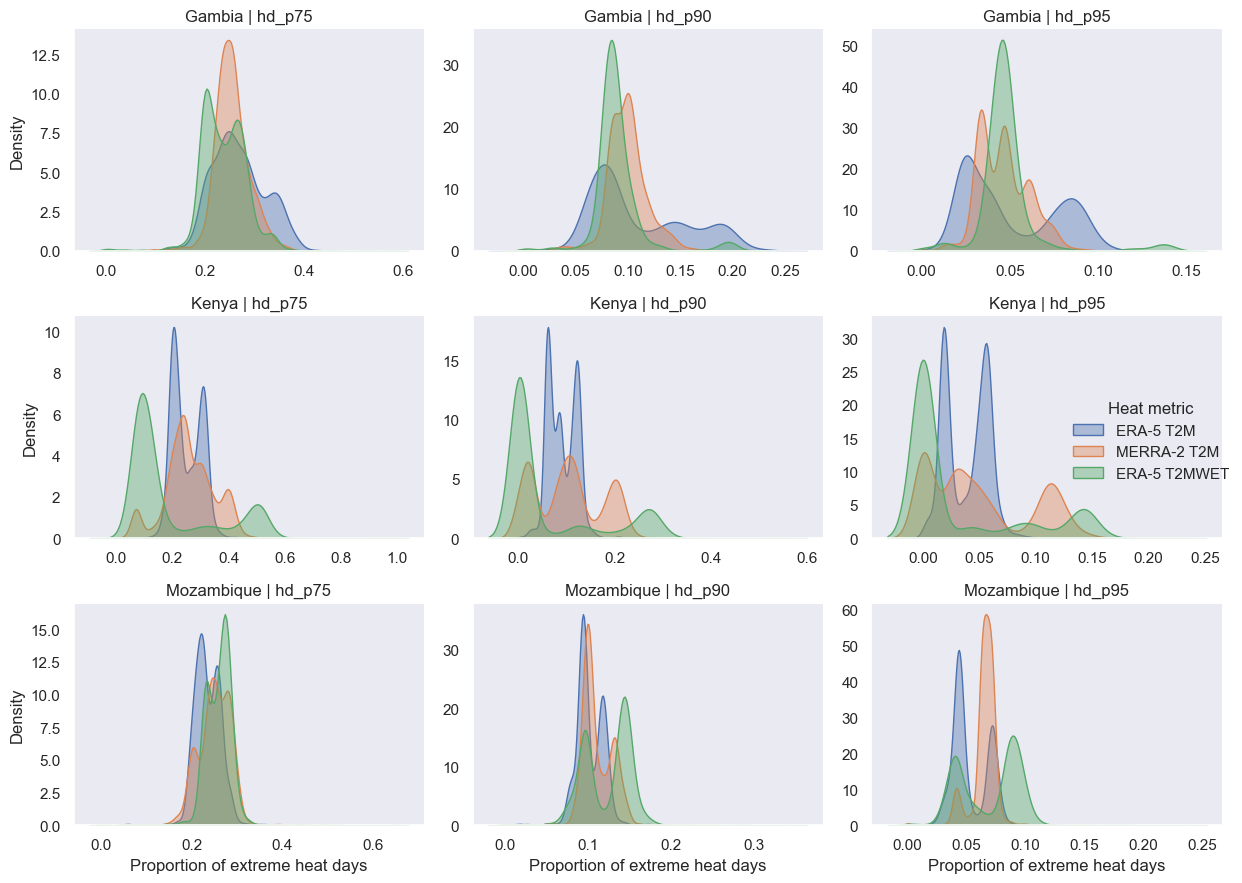

In [46]:
sns.set_theme(style="dark")

g = sns.FacetGrid(
    extreme_heat_data(),
    row="Country",
    col="heat_def",
    hue="Exposure metric",
    sharex=False,
    sharey=False,
    height=3,
    aspect=1.2,
)

g.map(sns.kdeplot, "proportion", fill=True, alpha=0.4, bw_adjust=1)

g.add_legend(title="Heat metric")

# Improve layout
g.set_axis_labels("Proportion of extreme heat days", "Density")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

plt.tight_layout()
plt.show()

In [ ]:
sns.